# P3 - Using **cartopy** for mapping

#### Importing of the necessary packages for the plots

In [1]:
import cartopy.crs as ccrs
import cartopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import cartopy.feature as cfeature

### 1. Map of the Antarctic continent and the Southern Ocean starting from 60°S

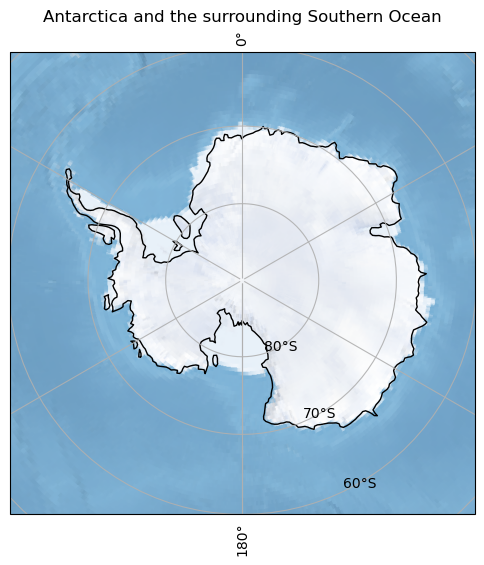

In [7]:
# Axes and figure
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.SouthPolarStereo())      

# Extent of Antarctica and the Southern Ocean
extent = [-180, 180, -90, -60]             
ax.set_extent(extent, crs=ccrs.PlateCarree())           

# Labels and their placements
gl= ax.gridlines(draw_labels=True, alpha=0.9)  
gl.right_labels= False
gl.top_labels= True

# Adding features
ax.coastlines(resolution='110m')                     
ax.add_feature(cartopy.feature.LAND)
ax.add_feature(cartopy.feature.OCEAN, facecolor='lightblue')
ax.stock_img()
plt.title('Antarctica and the surrounding Southern Ocean')

plt.show()

#### Figure explanation:
This map uses a South Polar Stereographic projection because it is the best suited to show the southern polar region. This projection preserves the shape of Antarctica while still showing the surrounding Southern Ocean until 60 degrees South. Coastlines with a high resolution were added to show the outline of Antarctica clearly and the ax.stock_img() made the image look more visually appealling.

### 2. Map of the South Atlantic, from 20°S to 50°S. The map shows the following coastal cities: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo.

[Location(Cape Town, City of Cape Town, Western Cape, 8001, South Africa, (-33.9288301, 18.4172197, 0.0)), Location(Walvis Bay, Erongo Region, 13013, Namibia, (-22.9557607, 14.5071125, 0.0)), Location(Rio de Janeiro, Região Geográfica Imediata do Rio de Janeiro, Região Metropolitana do Rio de Janeiro, Região Geográfica Intermediária do Rio de Janeiro, Rio de Janeiro, Southeast Region, Brazil, (-22.9110137, -43.2093727, 0.0)), Location(Montevideo, Uruguay, (-34.9058916, -56.1913095, 0.0))]


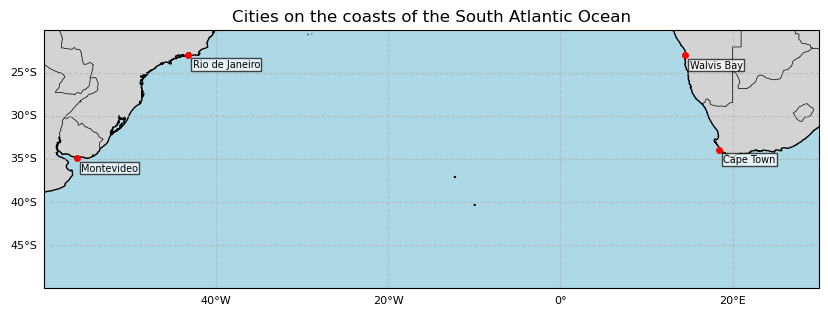

In [3]:
# Figure and axes
plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Extent of the South Atlantic region countaining the coastal cities
extent = [-60,30, -50, -20]
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Gridlines
gl= ax.gridlines(draw_labels=True, linestyle='--', alpha=0.6)
gl.right_labels = False
gl.top_labels= False
gl.xlabel_style = {'size':8}
gl.ylabel_style = {'size':8}

# Locations
geolocator= Nominatim(user_agent='map')
place = ['Cape Town', 'Walvis Bay', 'Rio de Janeiro', 'Montevideo']
address =[]
for p in place:
    loc = geolocator.geocode(p, language='en')
    address.append(loc)
print(address)

# For loop used to plot each location and their appropriate labelling
for p in range(len(place)):
    ax.plot(address[p].longitude, address[p].latitude,
        marker='o', color='red', markersize=4,
        transform=ccrs.PlateCarree())
    
    ax.text(address[p].longitude + 0.5, address[p].latitude -1.5, 
            place[p], 
            transform=ccrs.Geodetic(), 
            fontsize=7,
            bbox=dict(facecolor='white', alpha=0.7, pad=1),
            )
    
# Features
ax.coastlines(resolution='10m')
ax.add_feature(cartopy.feature.LAND,  facecolor='lightgray')
ax.add_feature(cartopy.feature.OCEAN, facecolor='lightblue')
ax.add_feature(cartopy.feature.BORDERS, linewidth=0.5)
plt.title('Cities on the coasts of the South Atlantic Ocean')

plt.show()

#### Figure explanation:
For this figure I was contemplating using either the EquidistantConic or the Plate Carre but I ended up choosing the Plate Carree projection because I wanted to show each city clearly while still maintaning the actual co-ordinate system. This projection allows for each city to be clearly interpreted without any distortion of the land or see. I further added symbols for each city and also a text box around their names so each one could be clearly read.

### 3. A series of 3 panels showing the use of different coastline resolutions from the GSHHG database in a map of False Bay. Resolutions: coarse/crude, intermediate and full.

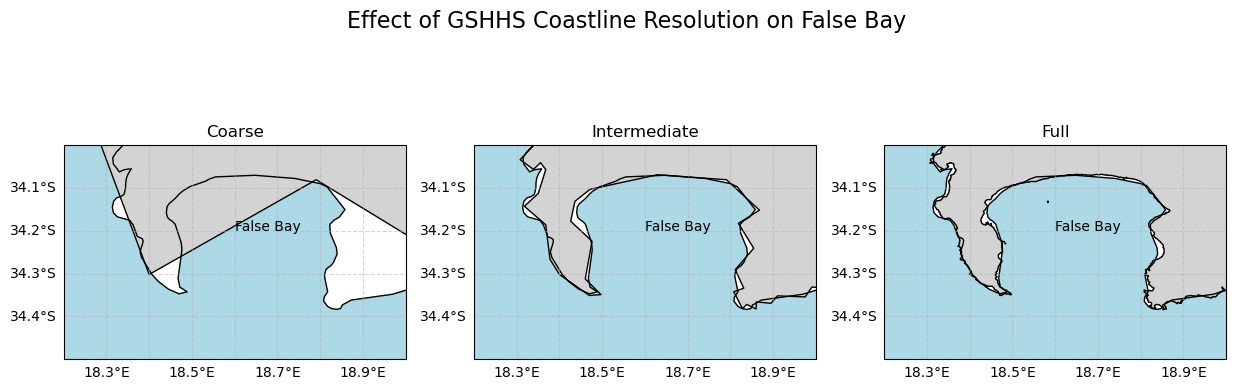

In [15]:
# Extent of False Bay
extent = [18.2, 19.0, -34.5, -34.0]

# Resolutions and titles for each plot
resolutions = ['c', 'i', 'f']  # coarse/crude, intermediate, full
titles = ['Coarse', 'Intermediate', 'Full']

# 3 figures and their axes
fig, axs = plt.subplots(1, 3, figsize=(15,5), subplot_kw={'projection': ccrs.PlateCarree()})

# For loop that uses the the 'resolution' and 'titles' variables to plot each subplot without having to type the same code repeatedly
for i, ax in enumerate(axs):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # Features with each resolution
    ax.add_feature(cfeature.GSHHSFeature(scale=resolutions[i]), facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.coastlines(resolution='10m')
    
    # Adds the False Bay text on the map
    ax.text(18.6, -34.2,
        'False Bay',
        transform=ccrs.PlateCarree(),
        fontsize=10)
    
    # Gridlines and titles for each figure
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(titles[i])

plt.suptitle("Effect of GSHHS Coastline Resolution on False Bay", fontsize=16)
plt.show()

#### Figure explanation:
For these series of various resolutions I used the Plate Carree projection to clearly show False Bay without any distortions of land, latitudes or longitudes as we just want to look at the resolution differences. 

I used a 'for' loop to plot each figure without having to repeat the same code for each resolution.

For these plots we see that as the resolution increases the details of False Bay's coastline gets better as well. For the first plot though we can see that the carse resolution struggles to plot most of the coastline, this is an example of how resolution should not be reduced to low when looking at small regions.